# `utils.clip_gradients` (per-tensor) vs `clip_grad_norm_` (global)

DINO 의 `utils.clip_gradients` 는 이름만 보면 `torch.nn.utils.clip_grad_norm_` 과
같아 보이지만 **클리핑 단위가 다르다**.

- global (`clip_grad_norm_`): 모든 파라미터 grad 를 **하나의 벡터**로 이어붙여 노름을 재고,
  **단 하나의 계수**를 전부에 곱한다 → 방향 보존.
  $$ g \leftarrow g \cdot \min\!\left(1, \frac{c}{\lVert g \rVert_{\text{all}}}\right) $$
- per-tensor (`utils.clip_gradients`): **텐서마다** 노름을 재고 **텐서마다 다른 계수**를 곱한다
  → 텐서 간 상대 크기가 바뀌므로 전체 gradient 방향이 회전한다.
  $$ g_p \leftarrow g_p \cdot \min\!\left(1, \frac{c}{\lVert g_p \rVert_2 + \varepsilon}\right)
     \quad \text{for each } p $$

필요 패키지: torch(2.4), plotly(6.9), kaleido
참고: 실제 DINO 구현을 import 해서 쓴다 (`/home/sungwoo/projects/swcho/dino/utils.py`).

In [1]:
import os
import sys
import copy

import torch
import torch.nn as nn
import plotly.graph_objects as go

sys.path.insert(0, "/home/sungwoo/projects/swcho/dino")
import utils  # DINO 의 utils.clip_gradients

torch.manual_seed(0)

HERE = os.path.dirname(os.path.abspath(__file__)) if "__file__" in globals() else os.getcwd()


def _show(fig):
    try:
        from IPython import get_ipython
        if get_ipython() is not None:  # VSCode 셀/Jupyter에서만 렌더링
            fig.show()
    except ImportError:
        pass


print(torch.__version__)

2.4.0+cu121


## 1. 실제 구현 확인

```python
def clip_gradients(model, clip):
    norms = []
    for name, p in model.named_parameters():
        if p.grad is not None:
            param_norm = p.grad.data.norm(2)     # ← 텐서 하나의 노름
            norms.append(param_norm.item())      # ← GPU 동기화 1회
            clip_coef = clip / (param_norm + 1e-6)
            if clip_coef < 1:                    # ← 작을 때는 건드리지 않음
                p.grad.data.mul_(clip_coef)
    return norms                                 # ← 클리핑 "전" 노름 리스트
```

In [2]:
import inspect
print(inspect.getsource(utils.clip_gradients))

def clip_gradients(model, clip):
    norms = []
    for name, p in model.named_parameters():
        if p.grad is not None:
            param_norm = p.grad.data.norm(2)
            norms.append(param_norm.item())
            clip_coef = clip / (param_norm + 1e-6)
            if clip_coef < 1:
                p.grad.data.mul_(clip_coef)
    return norms



## 2. 장난감 모델 + 가짜 gradient 심기

4층 `nn.Sequential`. **2번째 층만 노름 10.0**, 나머지는 0.5 로 맞춘다.
클리핑 임계값은 DINO 기본값 `--clip_grad 3.0`.

In [3]:
CLIP = 3.0
TARGET_NORMS = [0.5, 10.0, 0.5, 0.5]   # 층 1 만 "폭주"

model = nn.Sequential(
    nn.Linear(8, 8, bias=False),
    nn.Linear(8, 8, bias=False),
    nn.Linear(8, 8, bias=False),
    nn.Linear(8, 8, bias=False),
)
names = [n for n, _ in model.named_parameters()]

with torch.no_grad():
    for (n, p), target in zip(model.named_parameters(), TARGET_NORMS):
        g = torch.randn_like(p)
        p.grad = g / g.norm(2) * target      # 노름을 정확히 target 으로

orig_grads = {n: p.grad.detach().clone() for n, p in model.named_parameters()}
orig_norms = [orig_grads[n].norm(2).item() for n in names]
print(dict(zip(names, [round(v, 4) for v in orig_norms])))

{'0.weight': 0.5, '1.weight': 10.0, '2.weight': 0.5, '3.weight': 0.5}


## 3. per-tensor 클리핑 (`utils.clip_gradients`)

In [4]:
returned = utils.clip_gradients(model, CLIP)
per_tensor_norms = [p.grad.norm(2).item() for p in model.parameters()]

print("반환값(클리핑 전 노름) :", [round(v, 4) for v in returned])
print("클리핑 후 노름          :", [round(v, 4) for v in per_tensor_norms])
print("반환값 == 클리핑 전 노름? ",
      all(abs(a - b) < 1e-5 for a, b in zip(returned, orig_norms)))

반환값(클리핑 전 노름) : [0.5, 10.0, 0.5, 0.5]
클리핑 후 노름          : [0.5, 3.0, 0.5, 0.5]
반환값 == 클리핑 전 노름?  True


폭주한 층 1 만 정확히 $3.0$ 으로 잘렸고, **나머지 세 층은 손도 대지 않았다**
(`clip_coef < 1` 조건 덕분). 반환된 리스트는 **클리핑 전** 노름이라 로깅/진단용이다.

> 참고: `main_dino.py` 는 `param_norms = utils.clip_gradients(...)` 로 받아만 두고
> 실제로는 아무 데도 쓰지 않는다(죽은 변수). 직접 학습 모니터링에 붙이면 유용하다.

## 4. 같은 gradient 에 global 클리핑 (`clip_grad_norm_`)

In [5]:
model_g = copy.deepcopy(model)
with torch.no_grad():
    for n, p in model_g.named_parameters():
        p.grad = orig_grads[n].clone()       # 원본 grad 복원

total_norm = torch.nn.utils.clip_grad_norm_(model_g.parameters(), CLIP)
global_norms = [p.grad.norm(2).item() for p in model_g.parameters()]

expected_total = sum(v ** 2 for v in orig_norms) ** 0.5
print(f"글로벌 노름 = {total_norm.item():.4f}  (= sqrt(sum of squares) = {expected_total:.4f})")
print(f"공통 계수 c/||g|| = {CLIP / total_norm.item():.4f}")
print("클리핑 후 노름 :", [round(v, 4) for v in global_norms])
print(f"클리핑 후 글로벌 노름 = {sum(v ** 2 for v in global_norms) ** 0.5:.4f}")

글로벌 노름 = 10.0374  (= sqrt(sum of squares) = 10.0374)
공통 계수 c/||g|| = 0.2989
클리핑 후 노름 : [0.1494, 2.9888, 0.1494, 0.1494]
클리핑 후 글로벌 노름 = 3.0000


### 표로 비교

In [6]:
print(f"{'tensor':<10}{'원본':>10}{'per-tensor':>13}{'global':>10}")
for n, a, b, c in zip(names, orig_norms, per_tensor_norms, global_norms):
    print(f"{n:<10}{a:>10.4f}{b:>13.4f}{c:>10.4f}")
print(f"{'전체노름':<10}{expected_total:>10.4f}"
      f"{sum(v ** 2 for v in per_tensor_norms) ** 0.5:>13.4f}"
      f"{sum(v ** 2 for v in global_norms) ** 0.5:>10.4f}")

tensor            원본   per-tensor    global
0.weight      0.5000       0.5000    0.1494
1.weight     10.0000       3.0000    2.9888
2.weight      0.5000       0.5000    0.1494
3.weight      0.5000       0.5000    0.1494
전체노름         10.0374       3.1225    3.0000


**핵심 차이**: global 은 멀쩡했던 층들의 grad 까지 $0.5 \to 0.149$ 로 **1/3 이하로 억눌렀다**.
한 층의 폭주가 다른 모든 층의 학습률을 사실상 깎아버린 셈이다.
per-tensor 는 폭주한 층만 손보고 나머지는 그대로 둔다.
대신 전체 노름은 $3.1225$ 로 임계값 $3.0$ 을 **초과**한다 —
per-tensor 는 글로벌 노름을 보장하지 않는다.

## 5. gradient 방향은 얼마나 바뀌나 (코사인 유사도)

모든 grad 를 한 벡터로 이어붙여 원본과의 코사인 유사도를 잰다.
- global: 스칼라 배이므로 정확히 $1.0$ (방향 보존)
- per-tensor: 텐서별로 다른 계수 → $<1$ (방향 회전)

In [7]:
def flat(grads):
    return torch.cat([g.reshape(-1) for g in grads])


v_orig = flat([orig_grads[n] for n in names])
v_pt = flat([p.grad for p in model.parameters()])
v_gl = flat([p.grad for p in model_g.parameters()])

cos = nn.functional.cosine_similarity
print(f"cos(원본, per-tensor) = {cos(v_orig, v_pt, dim=0).item():.6f}")
print(f"cos(원본, global)     = {cos(v_orig, v_gl, dim=0).item():.6f}")

cos(원본, per-tensor) = 0.981116
cos(원본, global)     = 1.000000


## 6. `clip_coef < 1` 과 `+ 1e-6` 의 역할

- `+ 1e-6`: grad 가 정확히 0 인 텐서에서 $c/0 = \infty$ (또는 NaN) 을 막는 안정화 항.
- `if clip_coef < 1`: 계수가 1 이상이면 **곱하지 않는다** — 작은 grad 를 *키우지* 않는다.
  (계수를 무조건 곱하면 노름이 작은 텐서가 $3.0$ 으로 부풀려진다.)

In [8]:
tiny = nn.Linear(4, 4, bias=False)
tiny.weight.grad = torch.zeros_like(tiny.weight)       # grad 가 전부 0
n0 = utils.clip_gradients(tiny, CLIP)
print("zero-grad 텐서: 반환 노름 =", n0,
      "| 클리핑 후 =", tiny.weight.grad.norm(2).item(),
      "| finite? ", torch.isfinite(tiny.weight.grad).all().item())
print("clip_coef =", CLIP / (0.0 + 1e-6), "→ 1 이상이므로 곱하지 않음")

zero-grad 텐서: 반환 노름 = [0.0] | 클리핑 후 = 0.0 | finite?  True
clip_coef = 3000000.0 → 1 이상이므로 곱하지 않음


## 7. 숨은 비용: `.item()` 호출 = GPU 동기화 횟수

`norms.append(param_norm.item())` 은 텐서마다 `.item()` 을 부른다.
`.item()` 은 GPU→CPU 전송이라 **매번 동기화(sync)** 가 걸린다.
파라미터 텐서가 $N$ 개면 iteration 당 $N$ 번.
반면 `clip_grad_norm_` 은 `foreach` 커널로 노름을 모아 계산하고 동기화는 사실상 없다.

In [9]:
import vision_transformer as vits

vit = vits.vit_small(patch_size=16)
dino_student = nn.Sequential(vit, vits.DINOHead(vit.embed_dim, 65536))
n_backbone = len(list(vit.named_parameters()))
n_full = len(list(dino_student.named_parameters()))
print(f"ViT-S/16 backbone 파라미터 텐서 : {n_backbone}개")
print(f"+ DINOHead 포함 student 전체    : {n_full}개")
print(f"→ clip_gradients 는 iteration 당 .item() 을 최대 {n_full}회 = GPU sync {n_full}회")
print("→ clip_grad_norm_ 은 sync 0~1회")

ViT-S/16 backbone 파라미터 텐서 : 150개
+ DINOHead 포함 student 전체    : 158개
→ clip_gradients 는 iteration 당 .item() 을 최대 158회 = GPU sync 158회
→ clip_grad_norm_ 은 sync 0~1회


/home/sungwoo/miniforge3/envs/trellis/lib/python3.10/site-packages/torch/nn/utils/weight_norm.py:134: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


## 8. `--clip_grad 3.0` 의 의미가 다르다

per-tensor 기준 $3.0$ 은 "**각 텐서**가 최대 3.0" 이라는 뜻이다.
텐서 158 개가 모두 임계값에 걸려 있으면 글로벌 노름은
$\sqrt{158}\times 3.0 \approx 37.7$ 까지 커질 수 있다.
즉 `clip_grad_norm_(..., 3.0)` 과 같은 강도가 **전혀 아니다**.

In [10]:
import math
print(f"per-tensor 3.0 × {n_full}개 텐서 → 글로벌 노름 상한 ≈ {math.sqrt(n_full) * CLIP:.1f}")
print(f"이번 장난감 예제: per-tensor 후 글로벌 노름 = "
      f"{sum(v ** 2 for v in per_tensor_norms) ** 0.5:.4f} (> {CLIP})")

per-tensor 3.0 × 158개 텐서 → 글로벌 노름 상한 ≈ 37.7
이번 장난감 예제: per-tensor 후 글로벌 노름 = 3.1225 (> 3.0)


## 9. 시각화 — 텐서별 노름 비교

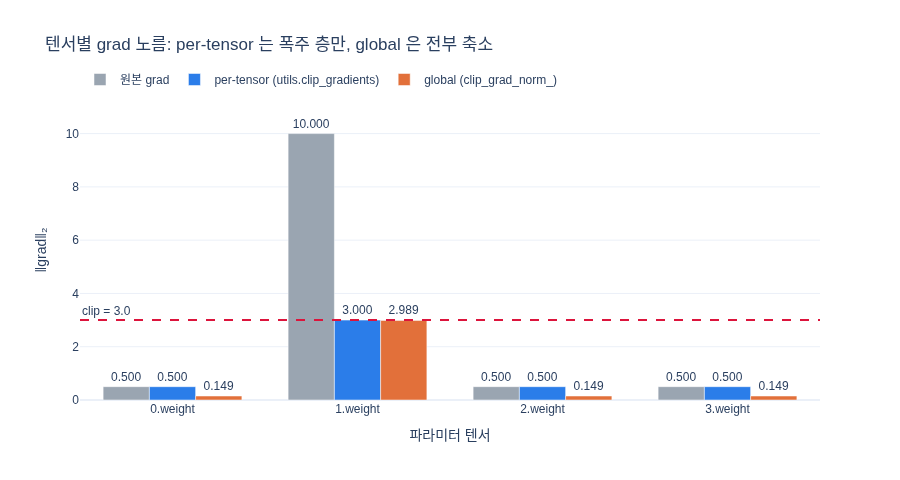

saved: /home/sungwoo/projects/swcho/dino/fm/training/.fm/hints/ab51f801-3bf0-4b39-808d-94db1ae1a964/expy.png


In [11]:
fig = go.Figure()
fig.add_trace(go.Bar(name="원본 grad", x=names, y=orig_norms,
                     marker_color="#9aa5b1",
                     text=[f"{v:.3f}" for v in orig_norms], textposition="outside"))
fig.add_trace(go.Bar(name="per-tensor (utils.clip_gradients)", x=names, y=per_tensor_norms,
                     marker_color="#2b7de9",
                     text=[f"{v:.3f}" for v in per_tensor_norms], textposition="outside"))
fig.add_trace(go.Bar(name="global (clip_grad_norm_)", x=names, y=global_norms,
                     marker_color="#e2703a",
                     text=[f"{v:.3f}" for v in global_norms], textposition="outside"))
fig.add_hline(y=CLIP, line_dash="dash", line_color="crimson",
              annotation_text="clip = 3.0", annotation_position="top left")
fig.update_layout(
    title="텐서별 grad 노름: per-tensor 는 폭주 층만, global 은 전부 축소",
    barmode="group", template="plotly_white",
    yaxis_title="‖grad‖₂", xaxis_title="파라미터 텐서",
    legend=dict(orientation="h", yanchor="bottom", y=1.02, x=0),
    width=900, height=480, bargap=0.25,
)
_show(fig)

png_path = os.path.join(HERE, "expy.png")
fig.write_image(png_path, scale=2)
print("saved:", png_path)

## 10. 호출 위치 (`main_dino.py` train_one_epoch)

```
loss.backward()                 (AMP: fp16_scaler.scale(loss).backward())
  └─ [AMP만] fp16_scaler.unscale_(optimizer)   ← 반드시 clip 전에
       └─ utils.clip_gradients(student, args.clip_grad)   # per-tensor
            └─ utils.cancel_gradients_last_layer(epoch, student, freeze_last_layer)
                 └─ optimizer.step()  (AMP: fp16_scaler.step / update)
                      └─ EMA teacher 갱신
```

AMP 에서 `unscale_` 을 먼저 하는 이유: `scale(loss).backward()` 직후의 grad 는
$2^{k}$ 배로 부풀려진 상태라, 그대로 클리핑하면 임계값 $3.0$ 이 스케일 배수만큼
잘못된 기준이 된다. 반드시 원래 스케일로 되돌린 뒤 클리핑해야 한다.

In [12]:
print("요약")
print(" per-tensor : 텐서마다 계수 → 층 간 상대 크기 변함 → 방향 회전(cos<1),"
      " 한 층 폭주가 다른 층을 억누르지 않음, sync N회, 글로벌 노름 보장 없음")
print(" global     : 계수 하나 → 방향 보존(cos=1), 폭주 층이 전체를 축소, sync 없음,"
      " 글로벌 노름 정확히 보장")

요약
 per-tensor : 텐서마다 계수 → 층 간 상대 크기 변함 → 방향 회전(cos<1), 한 층 폭주가 다른 층을 억누르지 않음, sync N회, 글로벌 노름 보장 없음
 global     : 계수 하나 → 방향 보존(cos=1), 폭주 층이 전체를 축소, sync 없음, 글로벌 노름 정확히 보장
